# Deployment5 motor raster scan — Friday 2026-07-17 (Utah time)

Standalone extraction + analysis of the antenna **motor raster scan**
(`run_tag == "motor_scan"`, Jul 17 20:26–21:28 UTC = 14:26–15:28 MDT).

**Where `run_tag` lives (established 2026-07-21):** it is a **header group *attribute***
(`f["header"].attrs["run_tag"]`), not a dataset — `eo.io.read_hdf5` merges group attrs
into the header dict, which is why `h["run_tag"]` works on the raw T5 files (see
`lidar.ipynb`). The filtered set preserves these attrs, so selection works directly on
`data/deployment5_filtered/` with plain h5py.

The trip has 42 files tagged `motor_scan`; this analysis uses the main raster block:
**29 contiguous files, no time gaps** (a few smaller tagged blocks later that evening
and two short tests on Jul 13/14 are not used here).

**Scan structure** (from per-integration motor telemetry): a serpentine grid with
**el as the fast axis** — el sweeps the full −180°→+180° range, then az steps **5.0°**
(313–314 counts) between passes. 54 el passes total, az from −180° to +80° (the scan
was stopped before completing the full ±180° az range).

Facts checked while locating the scan:

- Header **sync is sane** in these files (times match filename close-times to seconds;
  not in the 12% bad-sync population). `integration_time` = 0.537 s, 240 spectra/file.
- `metadata/motor`, `metadata/rfswitch`, and `metadata/potmon` have **exactly 1 record
  per integration** (240/240) in all 29 files → per-integration alignment is safe.
- `rfswitch` = `RFANT` for every integration (cycling paused during the scan).
- IMU (`metadata/imu_az/el`) returned `status: error` during the scan — motor counts and
  the az potentiometer are the only pointing records.
- Units **confirmed against the motor scan stack**: `scripts/motor_scan.py` commands
  degrees; `MotorClient` converts via `motor_cal.cal_motor()` = `picohost.motor.PicoMotor`
  constructor defaults `step_angle_deg=1.8`, `gear_teeth=113`, `microstep=1` →
  `steps = deg/1.8 × 113` = **62.7̄ counts/deg**, so ±11300 counts = exactly ±180.0°.
- **Independent potmon cross-check**: `pot_az_angle` (calibrated az potentiometer,
  323.7 °/V) tracks motor az with correlation 0.994 and near-unity slope over the full
  −180°→+80° range — confirming the counts→deg scale — but with local deviations up to
  ~15° (piecewise slopes 0.5–1.1; tether/pot mechanics). Treat motor counts as the
  commanded grid and the pot as the independent (noisier, mechanically lagged) readback.
- Motor zero point: the scan homes to step (0, 0) = the step-counter origin, not a
  sky-referenced azimuth; angles are accurate *relative* angles on that origin.
- Phase C wiring: key `0` = box-gnd, `4` = box-air (sky antenna, ~88 m Jul 17), `04`
  cross. Only key **`4`** is extracted.

The next two cells extract the raster files and save key `4` + per-integration
metadata + full header to a small sidecar file next to this notebook. Extraction is
**gated**: it runs only if the output file does not exist, or if `FORCE_EXTRACT = True`.

In [7]:
from pathlib import Path
import json

import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

# repo root = first parent dir containing the filtered data
REPO = Path.cwd().resolve()
while not (REPO / "data" / "deployment5_filtered").is_dir():
    if REPO.parent == REPO:
        raise FileNotFoundError("data/deployment5_filtered not found above cwd")
    REPO = REPO.parent
DATA_DIR = REPO / "data" / "deployment5_filtered"

OUT_PATH = REPO / "notebooks" / "christian" / "deployment5" / "motor_scan_20260717_key4.h5"
FORCE_EXTRACT = False  # set True to re-extract even if OUT_PATH exists

RUN_TAG = "motor_scan"
# the raster block: first/last file of the contiguous 29-file run (names = close times)
RASTER_LO, RASTER_HI = "corr_20260717_202824Z.h5", "corr_20260717_212831Z.h5"

COUNTS_PER_DEG = 113 / 1.8  # = 62.78, confirmed: PicoMotor step_angle_deg=1.8, gear_teeth=113, microstep=1

In [8]:
def parse_records(raw, fields):
    """Per-integration floats from a JSON list of record dicts; NaN for null records."""
    recs = json.loads(raw.decode() if isinstance(raw, bytes) else raw)
    out = np.full((len(recs), len(fields)), np.nan, dtype=np.float32)
    for i, r in enumerate(recs):
        if r:
            out[i] = [r.get(f, np.nan) for f in fields]
    return out


def select_files():
    names = sorted(p.name for p in DATA_DIR.glob("corr_*.h5"))
    names = [n for n in names if RASTER_LO <= n <= RASTER_HI]
    tagged = []
    for n in names:
        with h5py.File(DATA_DIR / n, "r") as f:
            if f["header"].attrs.get("run_tag") == RUN_TAG:
                tagged.append(n)
    return tagged


def extract(out_path):
    names = select_files()
    print(f"{len(names)} files tagged {RUN_TAG!r} in raster window")
    if len(names) != 29:
        print("WARNING: expected 29 files (2026-07-21 scan) — window or data changed?")

    data4, times, acc, azel, pot, rfsw, fidx, motor_raw = ([] for _ in range(8))
    for i, name in enumerate(names):
        with h5py.File(DATA_DIR / name, "r") as f:
            n = f["data/4"].shape[0]
            data4.append(f["data/4"][:])  # int32, lossless
            times.append(f["header/times"][:])
            acc.append(f["header/acc_cnt"][:])
            pos = parse_records(
                f["metadata/motor"][()],
                ["az_pos", "el_pos", "az_target_pos", "el_target_pos"],
            )
            assert len(pos) == n, f"{name}: {len(pos)} motor recs != {n} spectra"
            azel.append(pos)
            pv = parse_records(f["metadata/potmon"][()], ["pot_az_angle", "pot_az_voltage"])
            assert len(pv) == n, f"{name}: {len(pv)} potmon recs != {n} spectra"
            pot.append(pv)
            rfsw.append(np.array(json.loads(f["metadata/rfswitch"][()].decode()), dtype="S12"))
            fidx.append(np.full(n, i, dtype=np.int32))
            motor_raw.append(f["metadata/motor"][()])
            if i == 0:
                freqs = f["header/freqs"][:]
                hdr_attrs = dict(f["header"].attrs)
                hdr_dsets = {
                    k: f["header"][k][()]
                    for k in f["header"]
                    if k not in ("times", "acc_cnt", "freqs")
                }
                root_attrs = dict(f.attrs)

    data4 = np.concatenate(data4)
    times, acc = np.conhttps://sites.google.com/view/ixglobal21cmworkshop/homecatenate(times), np.concatenate(acc)
    azel, pot = np.concatenate(azel), np.concatenate(pot)
    order = np.argsort(times, kind="stable")  # files already time-ordered; belt & braces

    with h5py.File(out_path, "w") as o:
        comp = dict(compression="gzip", compression_opts=4, shuffle=True)
        o.create_dataset("data4", data=data4[order], **comp)
        o.create_dataset("times", data=times[order])
        o.create_dataset("acc_cnt", data=acc[order])
        for j, k in enumerate(["az_counts", "el_counts", "az_target_counts", "el_target_counts"]):
            o.create_dataset(k, data=azel[order, j])
        o.create_dataset("pot_az_angle_deg", data=pot[order, 0])
        o.create_dataset("pot_az_voltage", data=pot[order, 1])
        o.create_dataset("rfswitch", data=np.concatenate(rfsw)[order])
        o.create_dataset("file_index", data=np.concatenate(fidx)[order])
        o.create_dataset("file_names", data=np.array(names, dtype=h5py.string_dtype()))
        o.create_dataset("motor_raw_json", data=np.array(motor_raw, dtype=h5py.string_dtype()))
        o.create_dataset("freqs", data=freqs)
        hdr = o.create_group("header")  # full header of first file
        hdr.attrs.update(hdr_attrs)  # incl. run_tag, sync_time, integration_time, ...
        for k, v in hdr_dsets.items():
            hdr.create_dataset(k, data=v)
        o.attrs.update(root_attrs)  # filter_phase / filtered_keys / mux_copy_*
        o.attrs.update(
            source_dir=str(DATA_DIR), run_tag=RUN_TAG, key="4",
            window=f"{RASTER_LO} .. {RASTER_HI}",
            counts_per_deg=COUNTS_PER_DEG,
            counts_per_deg_provenance="confirmed: picohost.motor.PicoMotor defaults "
                "step_angle_deg=1.8, gear_teeth=113, microstep=1 (via motor_cal/"
                "MotorClient used by scripts/motor_scan.py); +-11300 counts = +-180 deg; "
                "cross-checked against pot_az_angle (corr 0.994)",
            note="run_tag=='motor_scan' raster block, Fri 2026-07-17 20:26-21:28Z; "
                 "serpentine scan, el fast axis, 5.0 deg az grid, az -180 to +80 deg; "
                 "az/el in raw motor counts; header/ copied from first file",
        )
    return len(names), data4.shape


if FORCE_EXTRACT or not OUT_PATH.exists():
    nfiles, shape = extract(OUT_PATH)
    print(f"extracted {nfiles} files -> {shape} spectra, {OUT_PATH.stat().st_size/1e6:.1f} MB")
else:
    print(f"exists, skipping extraction: {OUT_PATH}")

exists, skipping extraction: /home/christian/Documents/research/eigsep/data-analysis/notebooks/christian/deployment5/motor_scan_20260717_key4.h5


In [9]:
# load the sidecar file (standalone analysis starts here) and sanity-check
with h5py.File(OUT_PATH, "r") as f:
    d4 = f["data4"][:].astype(np.float32)
    t = f["times"][:]
    deg = 1.0 / f.attrs["counts_per_deg"]
    az, el = f["az_counts"][:] * deg, f["el_counts"][:] * deg
    pot_az = f["pot_az_angle_deg"][:]
    freqs = f["freqs"][:] / 1e6  # MHz
    rfsw = f["rfswitch"][:].astype(str)
    nfiles = f["file_names"].shape[0]

tm = (t - t[0]) / 60  # minutes since scan start
assert np.max(np.diff(t)) < 2.0, "unexpected time gap in raster"
print(f"{d4.shape} spectra from {nfiles} files, {tm[-1]:.1f} min contiguous,",
      f"{np.isnan(az).sum()} missing motor fixes, rfswitch {set(rfsw)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tm, az, ".", ms=1, label="motor az")
axes[0].plot(tm, el, ".", ms=1, label="motor el")
axes[0].plot(tm, pot_az, ".", ms=1, label="pot az (indep.)")
axes[0].set_xlabel("minutes since scan start")
axes[0].set_ylabel("angle [deg]")
axes[0].legend(loc="lower right", markerscale=8)
axes[1].plot(az, pot_az, ".", ms=1)
lim = [-185, 85]
axes[1].plot(lim, lim, "k--", lw=0.8, label="1:1")
axes[1].set_xlabel("motor az [deg]")
axes[1].set_ylabel("pot az [deg]")
axes[1].legend()
axes[1].set_title("potentiometer vs motor azimuth")
fig.suptitle("raster pointing: el fast axis (±180°), az steps 5° per pass")
fig.tight_layout()

(6960, 1024) spectra from 29 files, 62.3 min contiguous, 0 missing motor fixes, rfswitch {np.str_('RFANT')}


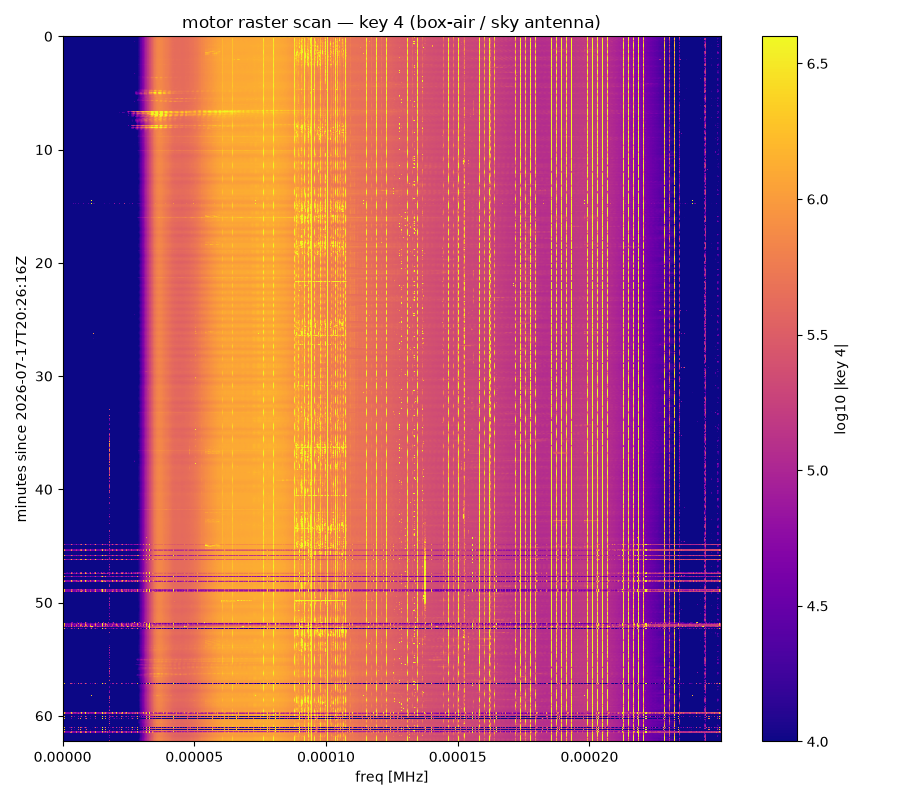

In [10]:
# waterfall: time on y (downward from scan start), frequency on x
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(
    np.log10(np.abs(d4) + 1), aspect="auto", cmap="plasma",
    extent=[freqs[0], freqs[-1], tm[-1], 0], vmin=4, vmax=6.6,
    interpolation="nearest",
)
ax.set_xlabel("freq [MHz]")
ax.set_ylabel(f"minutes since {np.datetime64(int(t[0]), 's')}Z")
fig.colorbar(im, ax=ax, label="log10 |key 4|")
ax.set_title("motor raster scan — key 4 (box-air / sky antenna)")
fig.tight_layout()

---
## Analysis

Analysis cells go below — everything needed is loaded from `OUT_PATH` above. Reminders:
comb tones every 16th channel (+ ±1 spillover); non-radiometer noise; el is the fast
axis (full ±180° sweep per pass) with az stepping 5° between passes, so beam structure
vs el repeats every ~69 s; `az_target_counts`/`el_target_counts` distinguish commanded
slews from tracking; the first ~2 min include the slew from az 0 to the −180° start.